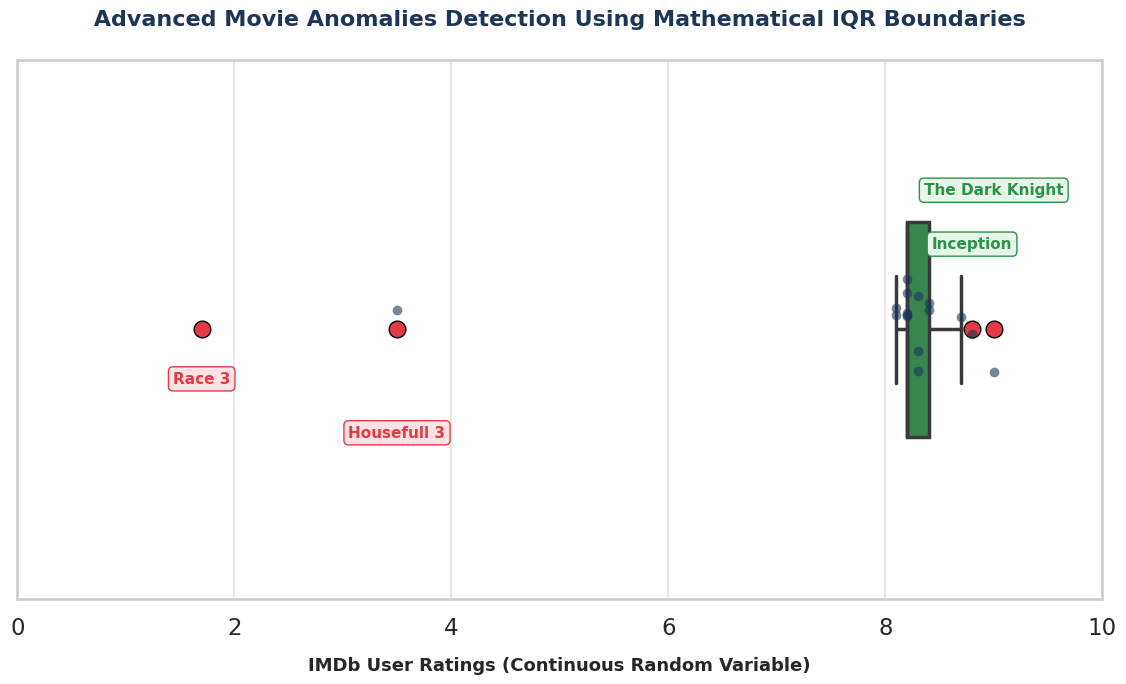

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("/Movie_Datasets.csv")

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid", {"grid.color": "#EAEAEE"})
sns.boxplot(
    x="Rating", data=df, color="#2b9348", width=0.4, linewidth=2.5,
    flierprops={"marker": "o", "markerfacecolor": "#e63946", "markersize": 12, "markeredgecolor": "black"}
)

sns.stripplot(x="Rating", data=df, color="#1d3557", size=7, alpha=0.6, jitter=0.1)
Q1 = df['Rating'].quantile(0.25)
Q3 = df['Rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Rating'] < lower_bound) | (df['Rating'] > upper_bound)]
for index, row in outliers.iterrows():
    if row['Rating'] < lower_bound:
        y_pos = 0.10 if row['Movie_Name'] == 'Race 3' else 0.20
        box_color = "#ffe3e3"
        text_color = "#e63946"
    else:
        y_pos = -0.15 if row['Movie_Name'] == 'Inception' else -0.25
        box_color = "#e8f5e9"
        text_color = "#2b9348"

    plt.text(
        x=row['Rating'], y=y_pos, s=row['Movie_Name'],
        color=text_color, fontweight='bold', fontsize=11, ha='center',
        bbox=dict(boxstyle="round,pad=0.3", fc=box_color, ec=text_color, lw=1)
    )

plt.xlabel("IMDb User Ratings (Continuous Random Variable)", fontsize=13, fontweight='bold', labelpad=12)
plt.title(" Advanced Movie Anomalies Detection Using Mathematical IQR Boundaries ", fontsize=16, fontweight='bold', pad=25, color='#1d3557')
plt.xlim(0, 10)

plt.savefig("advanced_portfolio_outliers.png", dpi=300, bbox_inches='tight')
plt.show()